This notebook aims to debug my current ccsa custom implementation and check wheter my adaptation can make it more parameter-independent. We will first focus on diminishing the potential differences with the NLOPT implementation, then provide possible alternatives for the adaptation of parameters like the trust region, the curvature, w, parameter for the control of the curvature update. Finally we will understand how stochasticity affects this and how we can change the acceptance criterion to be suitable for stochastic optimization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nlopt
import torch

## Unconstrained Stochastic Convex Optimization:

Let's try the stochastic optimization problem
$$
\min_{x \in \mathbb{R}^n} E[f(x,\xi)]
$$
where
$$
f(x,\xi) = \Vert A(x + \xi) \Vert_2^2
$$
and $A = A^T$ is an $n \times n$ real-symmetric matrix, while $\xi \in \mathbb{R}^n$

The expectation value $E[\cdots]$ is for $\xi$ drawn from i.i.d. Gaussian random variables $\xi_k \sim N(0,\sigma^2)$.

Analytically, the minimizer should simply be at $x = 0$ while the minimum is $ \sigma^2 \mathrm{tr}(A^2)$.

Note that $\nabla_x f = 2A(x + \xi)$.

Our starting guess will simply be `x = randn(n)`, and we'll use $A = I$ to start with.

In [2]:
from experiments import stoch_convex_unc_exp
from ccsa.optimizer import CCSAOptimizer
from ccsa.params import MMA_SigmaParams, MMA_RhoParams
import nlopt

# deterministic RNG for the experiment
n = 100
seed = 42
sigma_min = 1e-1
rng = np.random.RandomState(seed)
x_init = rng.randn(n)

# Initialize Customer Optimizer
rho_params = MMA_RhoParams(softening=0.5, min_growth=1.01, max_multiplier=10.0, decay=1.0)
sigma_params = MMA_SigmaParams(expand=1.2, contract=0.7, sigma_min=sigma_min,  rel_min=0.01, rel_max=10.0)

optimizer = CCSAOptimizer(
            params=[torch.tensor(x_init, dtype=torch.float32, requires_grad=False)],
            fun=None,   
            g=None,
            x0 = x_init,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            rho_params=rho_params,
            sigma_params=sigma_params,
            df=None,      
            dg=None
        )

# Initialize Nlopt Optimizer
opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", sigma_min)
opt.set_param("inner_maxeval", 5)


# Run experiments for the new implementation
for noise in [0.01]:
    for cond in [1]:
        stoch_convex_unc_exp(optimizer, opt, noise=noise, cond=cond, outer = 5000, rng=rng, x_init=x_init)




ImportError: cannot import name 'stoch_convex_unc_exp' from 'experiments' (unknown location)

## CONVEX STOCHASTIC OBJECTIVE DETERMINISTIC LINEAR CONSTRAINT

Let's define our first constrained optimization algorithm. We will start with a simple case in which we just take the above and modify with a simple linear constraint. 

$$
\min_{x \in \mathbb{R}^n} \; \mathbb{E}[f(x,\xi)] \quad \quad s.t. \quad c^T x - b \leq 0
$$

where  

$$
f(x,\xi) = \Vert A(x + \xi) \Vert_2^2, 
$$  

and $A = A^T$ is an $n \times n$ real-symmetric matrix, while $\xi \in \mathbb{R}^n$ is a random vector with $\mathbb{E}[\xi]=0$ and $\mathrm{Cov}(\xi) = \sigma_\xi^2 I$. We will divide it into 2 cases:

1.  Active Constraint (i.e. unconstrained solution is NOT in the feasible region). In this case the solution lies on the feasibility boundary and can be analytically computed by forming the lagrangian starting from the expected valued function (ignoring for the moment the noise related term)

$$
\mathcal{L}(x,\lambda) = x^T A^2 x + \lambda (c^T x - b).
$$

The KKT condition gives us

$$
\nabla_x \mathcal{L} = 2 A^2 x + \lambda c = 0 
\quad \Longrightarrow \quad 
x = -\frac{\lambda}{2} (A^2)^{-1} c.
$$

Impose the constraint \(c^T x = b\):

$$
c^T \Big(-\frac{\lambda}{2} (A^2)^{-1} c \Big) = b
\quad \Longrightarrow \quad
\lambda = -\frac{2b}{c^T (A^2)^{-1} c}.
$$

Hence the constrained optimizer is

$$
x^\ast_{\text{constr}} 
= \frac{b}{c^T (A^2)^{-1} c} \, (A^2)^{-1} c.
$$


To obtain the optimum we plug into the objective:

$$
F(x^\ast_{\text{constr}})
= (x^\ast_{\text{constr}})^T A^2 x^\ast_{\text{constr}} 
+ \sigma_\xi^2 \, \mathrm{tr}(A^2).
$$

The quadratic term evaluates to

$$
(x^\ast_{\text{constr}})^T A^2 x^\ast_{\text{constr}}
= \frac{b^2}{c^T (A^2)^{-1} c}.
$$

and the final optimal value is

$$
F^\ast_{\text{constr}} 
= \frac{b^2}{c^T (A^2)^{-1} c} 
+ \sigma_\xi^2 \, \mathrm{tr}(A^2).
$$



2. Inactive Constraint (i.e. unconstrained solution is in the feasible region). In this case, similarly as before, the expected optimum is $\sigma^2 \mathrm{tr}(A^2) $.  

---

As a baseline we implement the augmented lagrangian version of Adam, which is a state-of-the-art method for constrained stochastic optimization.  

The augmented Lagrangian for our problem is defined as  

$$
\mathcal{L}_\rho(x, \lambda) = \mathbb{E}[f(x,\xi)] + \lambda \, (c^\top x - d) + \tfrac{\rho}{2} \, (c^\top x - d)^2,
$$  

where $\lambda \ge 0$ is the Lagrange multiplier and $\rho > 0$ is a penalty parameter.  

At each iteration $k$ we should perform a stochastic Adam update on the primal variable $x$ using $g_k$, a stochastic estimate of the gradient of the augmented Lagrangian,  

$$
g_k = \nabla f(x_k, \xi_k) + (\lambda_k + \rho \, g(x_k)) c,
$$  

with constraint function $g(x) = c^\top x - d$.  

The dual variable is updated at each step according to  

$$
\lambda_{k+1} = \max \big( 0, \lambda_k + \rho \, g(x_{k+1}) \big).
$$  

This results in a single-loop primal-dual method where the primal variable is updated using Adam with stochastic gradients, and the dual variable is updated via a projected gradient descent step to enforce feasibility.


=== Running noise = 0.01, cond# = 100 ===
Random constraint: ||c||=1, b=-5
Analytic expected optimum (on expectation):
  active? True
  ||x*||=10.8753, λ*=0.0160915
  E[f(x*)]=0.0413543 (noise const=0.00112555)
Unconstrained baseline: E[f(x_uncon)]= 0.00112555, g(x_uncon)=5
Initial constraint g(x0)=-9.89578 (init_feasible=True)

AL-Adam finished:
  last f_est=0.0441083, g(x)=0.0212002, λ=0.0333597

nlopt σ=0.1: res=5, ||x||=11.9, g(x)=-0.576
CCSA σ=0.1: cumulative_wval=9948.99, weighted_evals=300.0, x_history_len=201
SLSQP success: True
SLSQP message: Optimization terminated successfully
SLSQP iterations: 9
SLSQP objective value: -1.9381760181496155
---- x_bar diagnostics ----
||x_bar - x_k||: 5.284971834434617
x_bar norm: 17.739448778113125
max |x_bar|: 4.19076458816805
SURROGATE: fbar = -1.9381760181496155 max gbar = 2.6645352591003757e-13
TRUE:      f = 11.224805964087995 max g = -8.379278187229893
----------------------------
SLSQP success: True
SLSQP message: Optimization terminat

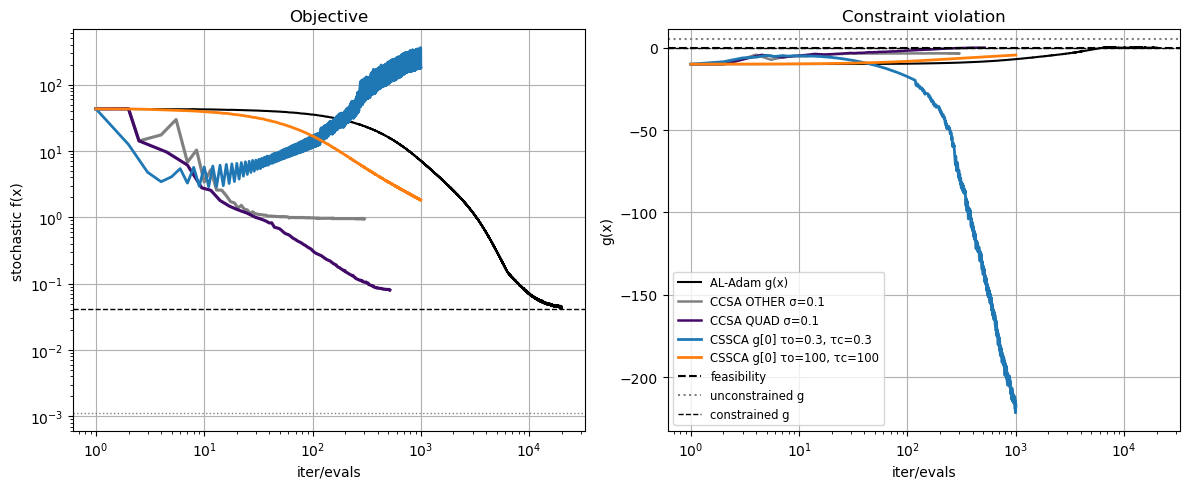

In [6]:
import numpy as np
import torch 
from ccsa.params import MMA_SigmaParams, MMA_RhoParams
from ccsa.optimizer import CCSAOptimizer
import nlopt

import os, random

from experiments.constrained_convex import stoch_convex_con_exp

# deterministic RNG for the experiment
n = 100

seed = 2

active_constraint = True  
init_feasible = True

np.random.seed(seed)

random.seed(seed)

rng = np.random.RandomState(seed)

torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)  # if using torch ops (may raise on non-deterministic ops)
# OpenMP / BLAS threading (see #3)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


# init point (local version using rng)
def init_point_local(n: int, c: np.ndarray, b: float, force_feasible: bool = False) -> np.ndarray:
    x0 = rng.randn(n)
    g0 = float(np.dot(c, x0) - b)
    if force_feasible:
        if g0 > 0:
            delta = ((b - np.dot(c, x0)) - 10.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    else:
        if g0 <= 0:
            delta = ((b - np.dot(c, x0)) + 10.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    return x0

# random linear constraint
c = rng.randn(n)
c /= np.linalg.norm(c)
x_uncon = np.zeros(n)
if active_constraint is None:
    b = rng.uniform(-1, 1)
elif active_constraint:
    b = np.dot(c, x_uncon) - 5.0
else:
    b = np.dot(c, x_uncon) + 5.0

x0 = init_point_local(n, c, b, force_feasible=init_feasible)

sigma_min = 1e-1
n = 100
rho_params = MMA_RhoParams(softening=0.5, min_growth=1.01, max_multiplier=10.0, decay=0.1)
sigma_params_run = MMA_SigmaParams(expand=1.2, contract=0.7, sigma_min=sigma_min, rel_min=0.01, rel_max=10.0)



ccsa_opt = CCSAOptimizer(
            params=x0.copy(),    # initial point
            fun=None,                # single-call oracle (value+grad from same xi)
            g=None,
            rho_params=rho_params,
            sigma_params=sigma_params_run,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,   # let MMAOptimizer request grad via fun(..., grad=True)
            x0=x0.copy(),
            use_quadratic_surrogates=True,
            conservative=False

        )

ccsa_quad = CCSAOptimizer(
            params=x0.copy(),    # initial point
            fun=None,                # single-call oracle (value+grad from same xi)
            g=None,
            rho_params=rho_params,
            sigma_params=sigma_params_run,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,   # let MMAOptimizer request grad via fun(..., grad=True)
            x0=x0.copy(),
            use_quadratic_surrogates=True              
        )


opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", sigma_min)
opt.set_param("inner_maxeval", 5)


# Run experiments for the new implementation
for noise in [0.01]:
    for cond in [100]:
        print(f"=== Running noise = {noise}, cond# = {cond} ===")
        stoch_convex_con_exp(ccsa_opt, ccsa_quad, opt, c=c, b=b, x0=x0, noise=noise, cond=cond, seed=seed, sigma_mins=[1e-1], maxiters_adam = 20000,
    mma_maxeval = 200,
    active_constraint = True,
    init_feasible =True,
    cssca_tau_obj=[0.3, 100], cssca_tau_cons=[0.3, 100]) #0.03, 0.1, 1.0, 10.0

=== Running noise = 0.0, cond# = 1 ===
Random constraint: ||c||=1, b=-5
Analytic expected optimum (on expectation):
  active? True
  ||x*||=5, λ*=10
  E[f(x*)]=25 (noise const=0)
Unconstrained baseline: E[f(x_uncon)]= 0, g(x_uncon)=5
Initial constraint g(x0)=-1 (init_feasible=True)

AL-Adam finished:
  last f_est=25, g(x)=-5.92198e-07, λ=10

nlopt σ=0.1: res=5, ||x||=5, g(x)=2.75e-07
CCSA σ=0.1: cumulative_wval=166.341, weighted_evals=660.0, x_history_len=201
4.3478260869565215 Percentage of
CSSCA (tau_obj=0.3, tau_cons=0.3, rho=1.0): last f=25, last g[0]=-4.28431e-11
2.9411764705882355 Percentage of
CSSCA (tau_obj=0.5, tau_cons=0.5, rho=1.0): last f=25, last g[0]=-2.71188e-11
50.0 Percentage of
2.380952380952381 Percentage of
3.1578947368421053 Percentage of
CSSCA (tau_obj=1.0, tau_cons=1.0, rho=1.0): last f=25, last g[0]=-2.43716e-12
3.7037037037037037 Percentage of
6.25 Percentage of
5.357142857142857 Percentage of
CSSCA (tau_obj=10.0, tau_cons=10.0, rho=1.0): last f=27.4058, last g

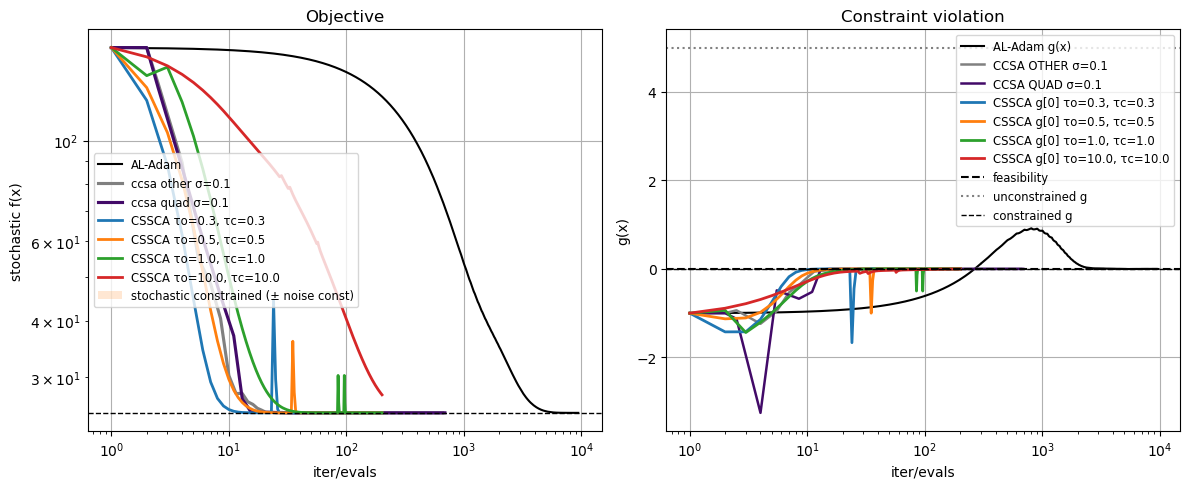

In [4]:
import numpy as np
import torch 
from ccsa.params import MMA_SigmaParams, MMA_RhoParams
from ccsa.optimizer import CCSAOptimizer
import nlopt

import os, random

from experiments.constrained_convex import stoch_convex_con_exp
seed = 2

active_constraint = True  
init_feasible = True

np.random.seed(seed)

random.seed(seed)

rng = np.random.RandomState(seed)

torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)  # if using torch ops (may raise on non-deterministic ops)
# OpenMP / BLAS threading (see #3)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


# init point (local version using rng)
def init_point_local(n: int, c: np.ndarray, b: float, force_feasible: bool = False) -> np.ndarray:
    x0 = rng.randn(n)
    g0 = float(np.dot(c, x0) - b)
    if force_feasible:
        if g0 > 0:
            delta = ((b - np.dot(c, x0)) - 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    else:
        if g0 <= 0:
            delta = ((b - np.dot(c, x0)) + 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    return x0

# random linear constraint
c = rng.randn(n)
c /= np.linalg.norm(c)
x_uncon = np.zeros(n)
if active_constraint is None:
    b = rng.uniform(-1, 1)
elif active_constraint:
    b = np.dot(c, x_uncon) - 5.0
else:
    b = np.dot(c, x_uncon) + 5.0

x0 = init_point_local(n, c, b, force_feasible=init_feasible)

sigma_min = 1e-1
n = 100
rho_params = MMA_RhoParams(softening=0.5, min_growth=1.01, max_multiplier=10.0, decay=0.1)
sigma_params_run = MMA_SigmaParams(expand=1.2, contract=0.7, sigma_min=sigma_min, rel_min=0.01, rel_max=10.0)



ccsa_opt = CCSAOptimizer(
            params=x0.copy(),    # initial point
            fun=None,                # single-call oracle (value+grad from same xi)
            g=None,
            rho_params=rho_params,
            sigma_params=sigma_params_run,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,   # let MMAOptimizer request grad via fun(..., grad=True)
            x0=x0.copy()               
        )

ccsa_quad = CCSAOptimizer(
            params=x0.copy(),    # initial point
            fun=None,                # single-call oracle (value+grad from same xi)
            g=None,
            rho_params=rho_params,
            sigma_params=sigma_params_run,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,   # let MMAOptimizer request grad via fun(..., grad=True)
            x0=x0.copy(),
            use_quadratic_surrogates=True              
        )


opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", sigma_min)
opt.set_param("inner_maxeval", 5)


# Run experiments for the new implementation
for noise in [0.0]:
    for cond in [1]:
        print(f"=== Running noise = {noise}, cond# = {cond} ===")
        stoch_convex_con_exp(ccsa_opt, ccsa_quad, opt, c=c, b=b, x0=x0, noise=noise, cond=cond, seed=seed, sigma_mins=[1e-1], maxiters_adam = 20000,
    mma_maxeval = 200,
    active_constraint = True,
    init_feasible =True,
    cssca_tau_obj=[0.3, 0.5, 1.0, 10.0], cssca_tau_cons=[0.3, 0.5, 1.0, 10.0])

In [1]:
import numpy as np
import torch 
from ccsa.params import MMA_SigmaParams, MMA_RhoParams
from ccsa.optimizer import CCSAOptimizer
import nlopt

import os, random

from experiments import stoch_convex_con_exp

seed = 2

active_constraint = True  
init_feasible = True

np.random.seed(seed)

random.seed(seed)

rng = np.random.RandomState(seed)

torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)  # if using torch ops (may raise on non-deterministic ops)
# OpenMP / BLAS threading (see #3)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


# init point (local version using rng)
def init_point_local(n: int, c: np.ndarray, b: float, force_feasible: bool = False) -> np.ndarray:
    x0 = rng.randn(n)
    g0 = float(np.dot(c, x0) - b)
    if force_feasible:
        if g0 > 0:
            delta = ((b - np.dot(c, x0)) - 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    else:
        if g0 <= 0:
            delta = ((b - np.dot(c, x0)) + 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    return x0

# random linear constraint
c = rng.randn(n)
c /= np.linalg.norm(c)
x_uncon = np.zeros(n)
if active_constraint is None:
    b = rng.uniform(-1, 1)
elif active_constraint:
    b = np.dot(c, x_uncon) - 5.0
else:
    b = np.dot(c, x_uncon) + 5.0

x0 = init_point_local(n, c, b, force_feasible=init_feasible)

sigma_min = 1e-1
n = 100
rho_params = MMA_RhoParams(softening=0.5, min_growth=1.01, max_multiplier=10.0, decay=0.1)
sigma_params_run = MMA_SigmaParams(expand=1.2, contract=0.7, sigma_min=sigma_min, rel_min=0.01, rel_max=10.0)



ccsa_opt = CCSAOptimizer(
            params=x0.copy(),    # initial point
            fun=None,                # single-call oracle (value+grad from same xi)
            g=None,
            rho_params=rho_params,
            sigma_params=sigma_params_run,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,   # let MMAOptimizer request grad via fun(..., grad=True)
            x0=x0.copy()               
        )

ccsa_quad = CCSAOptimizer(
            params=x0.copy(),    # initial point
            fun=None,                # single-call oracle (value+grad from same xi)
            g=None,
            rho_params=rho_params,
            sigma_params=sigma_params_run,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,   # let MMAOptimizer request grad via fun(..., grad=True)
            x0=x0.copy(),
            use_quadratic_surrogates=True              
        )


opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", sigma_min)
opt.set_param("inner_maxeval", 5)


# Run experiments for the new implementation
for noise in [0.1]:
    for cond in [1]:
        print(f"=== Running noise = {noise}, cond# = {cond} ===")
        stoch_convex_con_exp(ccsa_opt, ccsa_quad, opt, c=c, b=b, x0=x0, noise=noise, cond=cond, seed=seed, sigma_mins=[1e-1], maxiters_adam = 20000,
    mma_maxeval = 200,
    active_constraint = True,
    init_feasible =True,
    cssca_tau_obj=[0.3, 0.5, 1.0, 10.0], cssca_tau_cons=[0.3, 0.5, 1.0, 10.0])

NameError: name 'n' is not defined

Using diagonal exponential-quadratic objective n=100, noise=0.0, m in [0.001,1]
Linear constraint: ||c||=1, b=-5
Analytic expected optimum (on expectation):
  active? True
  ||x*||=8.19115, λ*=0.0441513
  E[f(x*)]=1.1167
Unconstrained baseline: E[f(0)]= 1, g(0)=5
Initial constraint g(x0)=-1 (init_feasible=True)

AL-Adam finished:
  last f_est=8.04772, g(x)=-0.0671381, λ=0.298034

nlopt σ=0.001: res=5, ||x||=8.19, g(x)=5.03e-07


/Users/antoniovaragnolo/Desktop/Research/CCSA/experiments/convex_constrained2.py:154: RuntimeWarning: overflow encountered in exp
  val = float(np.exp(quad))


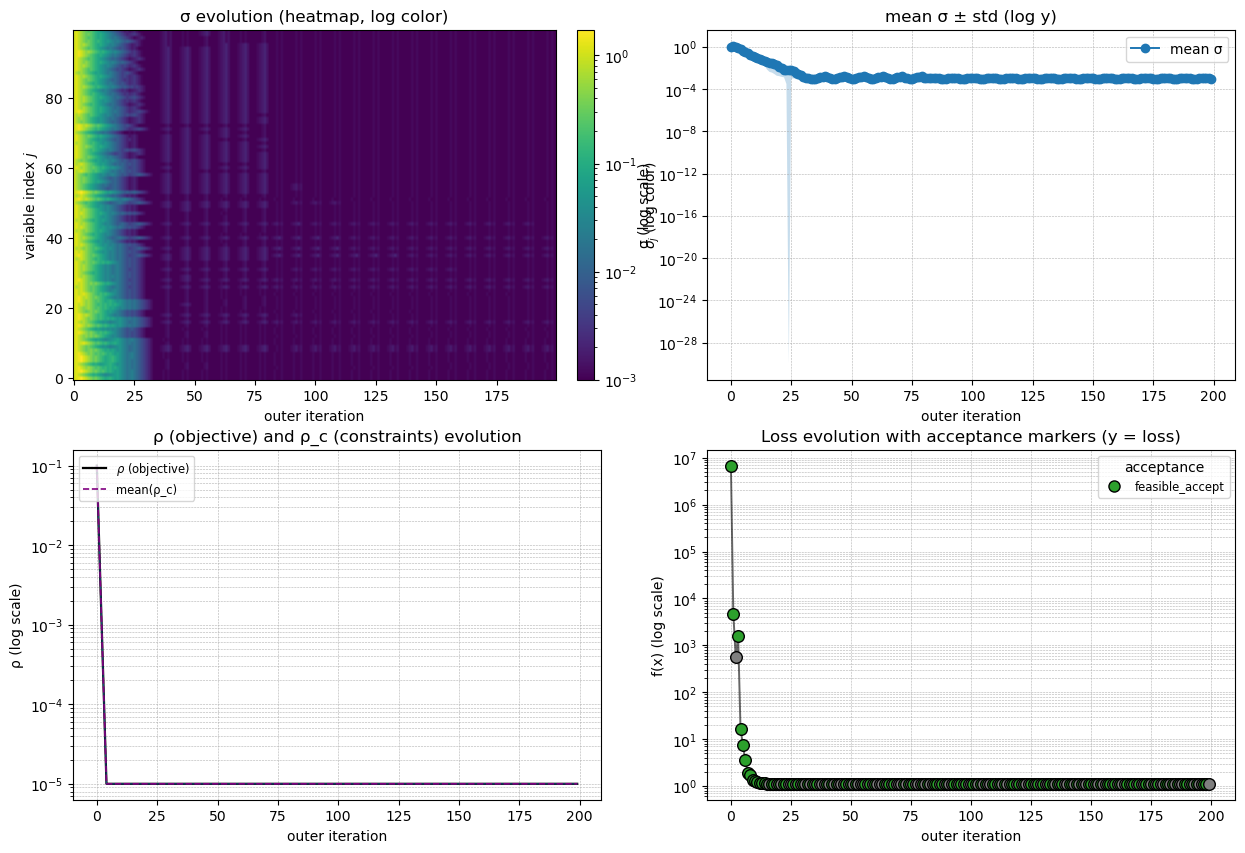

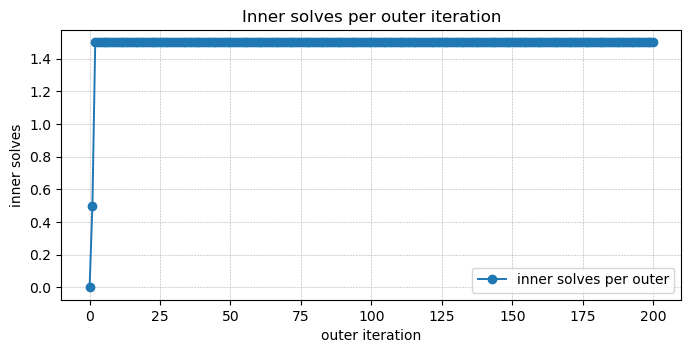


=== MMA Diagnostic Summary ===
Recorded outer iterations (f history): 201
Sigma: final mean = 1.001e-03, final std = 4.358e-06
Rho (objective): final = 1.000e-05
Rho_c (constraints): shape = (200, 1), final mean = 1.000e-05

Acceptance counts:
Counter({'feasible_accept': 101, 'feasibility_min': 99})

Average inner solves per outer step (observed): 1.49
CCSA σ=0.001: cumulative_wval=1039.81, weighted_evals=300.0, x_history_len=201
100.0 Percentage of
CSSCA (tau_obj=0.1, tau_cons=0.1, rho=1.0): last f=5.98481e+09, last g[0]=-6
100.0 Percentage of
100.0 Percentage of
100.0 Percentage of
100.0 Percentage of
CSSCA (tau_obj=1.0, tau_cons=1.0, rho=1.0): last f=6.12666e+07, last g[0]=-3
100.0 Percentage of
100.0 Percentage of
100.0 Percentage of
100.0 Percentage of
100.0 Percentage of
100.0 Percentage of
100.0 Percentage of
100.0 Percentage of
100.0 Percentage of
100.0 Percentage of
100.0 Percentage of
100.0 Percentage of
100.0 Percentage of
100.0 Percentage of
100.0 Percentage of
84.21052631

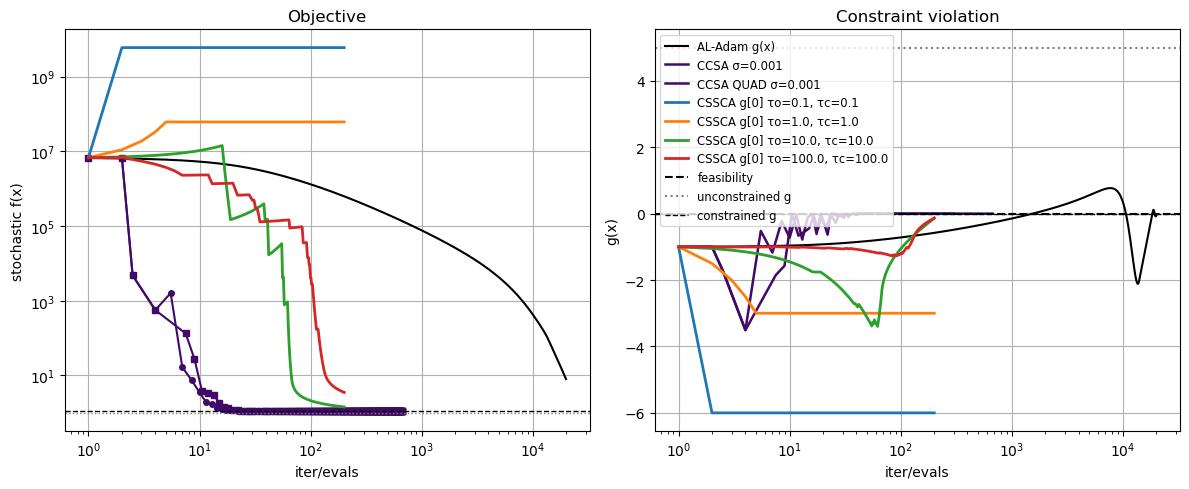

Returned x_star norm: 8.191146090639952
Returned expected value at x_star: 1.1167002828779518


In [3]:
# run_expquad.py
import numpy as np
import torch
import nlopt
import os, random
from ccsa.params import MMA_SigmaParams, MMA_RhoParams
from ccsa.optimizer import CCSAOptimizer
from experiments.convex_constrained2 import stoch_expquad_diag_exp

# reproducibility
seed = 1
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# problem params
n = 100
active_constraint = True
init_feasible = True
rng = np.random.RandomState(seed)

# init x0 helper
def init_point_local(n: int, c: np.ndarray, b: float, force_feasible: bool = False) -> np.ndarray:
    x0 = rng.randn(n)
    g0 = float(np.dot(c, x0) - b)
    if force_feasible:
        if g0 > 0:
            delta = ((b - np.dot(c, x0)) - 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    else:
        if g0 <= 0:
            delta = ((b - np.dot(c, x0)) + 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    return x0

# random linear constraint
c = rng.randn(n)
c /= np.linalg.norm(c)
x_uncon = np.zeros(n)
if active_constraint is None:
    b = rng.uniform(-1, 1)
elif active_constraint:
    b = np.dot(c, x_uncon) - 5.0
else:
    b = np.dot(c, x_uncon) + 5.0

x0 = init_point_local(n, c, b, force_feasible=init_feasible)

# optimizer settings
sigma_min = 1e-3
rho_params = MMA_RhoParams(softening=0.5, min_growth=1.01, max_multiplier=10.0, decay=0.1)
sigma_params_run = MMA_SigmaParams(expand=1.2, contract=0.7, sigma_min=sigma_min, rel_min=0.01, rel_max=10.0)

ccsa_opt = CCSAOptimizer(
    params=x0.copy(),
    fun=None,
    g=None,
    rho_params=rho_params,
    sigma_params=sigma_params_run,
    bounds=None,
    rho_init=1.0,
    max_inner=5,
    df=None,
    x0=x0.copy(),
    use_quadratic_surrogates=True,
    conservative=False
)



ccsa_quad = CCSAOptimizer(
    params=x0.copy(),
    fun=None,
    g=None,
    rho_params=rho_params,
    sigma_params=sigma_params_run,
    bounds=None,
    rho_init=1.0,
    max_inner=5,
    df=None,
    x0=x0.copy(),
    use_quadratic_surrogates=True
)

opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", sigma_min)
opt.set_param("inner_maxeval", 5)

# run the experiment
results = stoch_expquad_diag_exp(
    optimizer=ccsa_opt,#
    optimizer_quad=ccsa_quad,
    optimizer_nlopt=opt,
    noise=0.0,
    cond=1,
    c=c, b=b, x0=x0,
    sigma_mins=[sigma_min],
    seed=seed,
    maxiters_adam=20000,
    mma_maxeval=200,
    active_constraint=active_constraint,
    init_feasible=init_feasible,
    cssca_tau_obj=[0.1, 1.0, 10.0, 100.0], 
    cssca_tau_cons=[0.1, 1.0, 10.0, 100.0],
    cssca_samples_per_iter=1,
    curv_change='large'
)

print("Returned x_star norm:", np.linalg.norm(results["x_star"]))
print("Returned expected value at x_star:", results["val_star"])

Rotation angle θ = 2.7394
Constraint ||c||=1.0000, b=-0.5000
SLSQP success: True
SLSQP message: Optimization terminated successfully
SLSQP iterations: 2
SLSQP objective value: -0.053306403454075904
---- x_bar diagnostics ----
||x_bar - x_k||: 0.008765301878942993
x_bar norm: 1.9679847991140536
max |x_bar|: 1.9529195281663436
SURROGATE: fbar = -0.053306403454075904 max gbar = -0.0013832270551894644
TRUE:      f = -0.05358239600378405 max g = -0.00215153222547948
----------------------------
SLSQP success: True
SLSQP message: Optimization terminated successfully
SLSQP iterations: 2
SLSQP objective value: -0.05480342560120793
---- x_bar diagnostics ----
||x_bar - x_k||: 0.008980102858811512
x_bar norm: 1.960133498409978
max |x_bar|: 1.9445863099483944
SURROGATE: fbar = -0.05480342560120793 max gbar = -0.0035466592216265515
TRUE:      f = -0.05511384670026612 max g = -0.0043530816951748985
----------------------------
SLSQP success: True
SLSQP message: Optimization terminated successfully


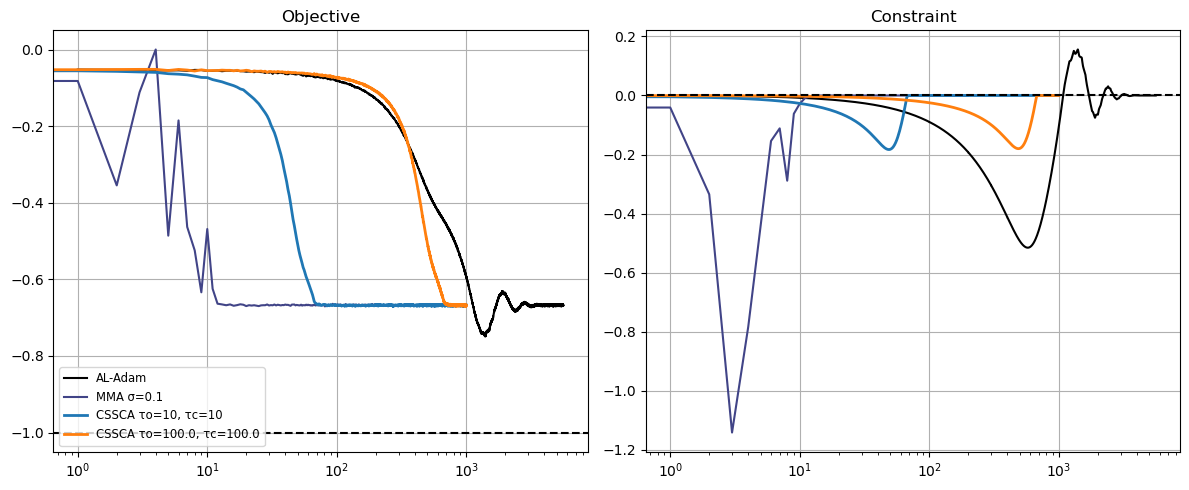

{'x_al': array([0.41802457, 0.64077681]),
 'hist_al': {'iter': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
   88,
   89,
   90,
   91,
   92,
   93,
   94,
   95,
   96,
   97,
   98,
   99,
   100,
   101,
   102,
   103,
   104,
   105,
   106,
   107,
   108,
   109,
   110,
   111,
   112,
   113,
   114,
   115,
   116,
   117,
   118,
   119,
   120,
   121,
   122,
   123,
   124,
   125,
   126,
   127,
   128,
   129,
   130,
   131,

In [1]:
import numpy as np
import torch
import nlopt
import os, random

from ccsa.params import MMA_SigmaParams, MMA_RhoParams
from ccsa.optimizer import CCSAOptimizer

from experiments.constrained_convex3 import rotated_exp_stoch_constrained_exp


# ============================================================
# Deterministic setup
# ============================================================
seed = 2
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

rng = np.random.RandomState(seed)

# ============================================================
# Problem dimension (NOW 2D)
# ============================================================
n = 2


# ============================================================
# Linear constraint
# ============================================================
c = rng.randn(n)
c /= np.linalg.norm(c)

x_uncon = np.zeros(n)

active_constraint = True
init_feasible = True

if active_constraint:
    b = np.dot(c, x_uncon) - 0.5
else:
    b = np.dot(c, x_uncon) + 0.5


def init_point_local(n, c, b, force_feasible=False):
    x0 = rng.randn(n)
    g0 = float(np.dot(c, x0) - b)

    if force_feasible:
        if g0 > 0:
            delta = (b - np.dot(c, x0)) * c / (np.dot(c, c))
            x0 = x0 + delta
    else:
        if g0 <= 0:
            delta = (b - np.dot(c, x0)) * c / (np.dot(c, c))
            x0 = x0 + delta

    return x0


x0 = init_point_local(n, c, b, force_feasible=init_feasible)


# ============================================================
# CCSA Optimizers (unchanged structure)
# ============================================================
sigma_min = 1e-1

rho_params = MMA_RhoParams(
    softening=0.5,
    min_growth=1.01,
    max_multiplier=10.0,
    decay=0.1
)

sigma_params_run = MMA_SigmaParams(
    expand=1.2,
    contract=0.7,
    sigma_min=sigma_min,
    rel_min=0.01,
    rel_max=10.0
)

ccsa_opt = CCSAOptimizer(
    params=x0.copy(),
    fun=None,
    g=None,
    rho_params=rho_params,
    sigma_params=sigma_params_run,
    bounds=None,
    rho_init=1.0,
    max_inner=5,
    df=None,
    x0=x0.copy(),
    use_quadratic_surrogates=False,
    conservative=False
)

ccsa_quad = CCSAOptimizer(
    params=x0.copy(),
    fun=None,
    g=None,
    rho_params=rho_params,
    sigma_params=sigma_params_run,
    bounds=None,
    rho_init=1.0,
    max_inner=5,
    df=None,
    x0=x0.copy(),
    use_quadratic_surrogates=True
)

# ============================================================
# NLopt
# ============================================================
opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", sigma_min)
opt.set_param("inner_maxeval", 5)


n = 2
opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", 1e-1)
opt.set_param("inner_maxeval", 5)

rotated_exp_stoch_constrained_exp(
    ccsa_opt,
    ccsa_quad,
    opt,
    a=10.0,
    tau=0.01,
    noise_std=0.001,
    c=c,
    b=b,
    x0=x0,
    seed=seed,
    sigma_mins=[1e-1],
    maxiters_adam=10000,
    mma_maxeval=200,
    cssca_tau_obj=[10, 100.0],
    cssca_tau_cons=[10, 100.0],
)
